In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path(
    "/Users/elenachen/Desktop/Environment_LivestockManure_E_All_Data_(Normalized)"
)

DATA_FILE = DATA_DIR / "Environment_LivestockManure_E_All_Data_(Normalized).csv"

DATA_FILE

PosixPath('/Users/elenachen/Desktop/Environment_LivestockManure_E_All_Data_(Normalized)/Environment_LivestockManure_E_All_Data_(Normalized).csv')

In [2]:
#Read only the required data
ANALYSIS_YEARS = [2013, 2023]

TOP_LEVEL_ITEMS = [
    "All Animals",
    "Cattle",
    "Buffalo",
    "Sheep and Goats",
    "Swine",
    "Poultry Birds",
    "Horses",
    "Mules and Asses",
    "Camels and Llamas",
]

columns = [
    "Area Code",
    "Area",
    "Item",
    "Element",
    "Year",
    "Unit",
    "Value",
    "Flag",
]

chunks = []

for chunk in pd.read_csv(
    DATA_FILE,
    usecols=columns,
    chunksize=250_000,
    low_memory=False,
):
    filtered = chunk[
        chunk["Year"].isin(ANALYSIS_YEARS)
        & chunk["Item"].isin(TOP_LEVEL_ITEMS)
    ].copy()

    chunks.append(filtered)

df = pd.concat(chunks, ignore_index=True)

print(f"Rows retained: {len(df):,}")
df.head()

Rows retained: 32,286


,Area Code,Area,Item,Element,Year,Unit,Value,Flag
0,2,Afghanistan,Horses,Stocks,2013,An,1.710000e+05,A
1,2,Afghanistan,Horses,Stocks,2023,An,1.512900e+04,I
2,2,Afghanistan,Horses,Amount excreted in manure (N content),2013,kg,6.833194e+06,E
3,2,Afghanistan,Horses,Amount excreted in manure (N content),2023,kg,6.045579e+05,E
4,2,Afghanistan,Horses,Manure left on pasture (N content),2013,kg,6.491534e+06,E


In [3]:
from pathlib import Path

DATA_DIR = Path(
    "/Users/elenachen/Desktop/Environment_LivestockManure_E_All_Data_(Normalized)"
)

DATA_FILE = DATA_DIR / "Environment_LivestockManure_E_All_Data_(Normalized).csv"

print(DATA_FILE)
print("File exists:", DATA_FILE.exists())

/Users/elenachen/Desktop/Environment_LivestockManure_E_All_Data_(Normalized)/Environment_LivestockManure_E_All_Data_(Normalized).csv
File exists: True


In [4]:
#Clean data and remove regional aggregates

df["Area Code"] = pd.to_numeric(df["Area Code"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

country_df = df[
    (df["Area Code"] < 300)
    & (df["Area"] != "China")
].copy()

print("Rows:", f"{len(country_df):,}")
print("Areas:", country_df["Area"].nunique())
print("Years:", sorted(country_df["Year"].unique()))
print("Items:", country_df["Item"].nunique())
print("Elements:", country_df["Element"].nunique())

Rows: 25,686
Areas: 197
Years: [2013, 2023]
Items: 9
Elements: 10


In [5]:
#Inspect the data

print("Missing values:")
display(country_df.isna().sum().to_frame("Missing"))

print("\nElement and unit combinations:")
display(
    country_df.groupby(["Element", "Unit"])
    .size()
    .rename("Rows")
    .reset_index()
)

print("\nFAOSTAT flags:")
display(
    country_df["Flag"]
    .value_counts(dropna=False)
    .rename_axis("Flag")
    .reset_index(name="Rows")
)


Missing values:


,Missing
Area Code,0
Area,0
Item,0
Element,0
Year,0
Unit,0
Value,0
Flag,0



Element and unit combinations:


,Element,Unit,Rows
0,Amount excreted in manure (N content),kg,2608
1,Losses from manure treated (N content),kg,2608
2,Manure applied to soils (N content),kg,2608
3,Manure applied to soils that leaches (N content),kg,2608
4,Manure applied to soils that volatilises (N co...,kg,2608
5,Manure left on pasture (N content),kg,2608
6,Manure left on pasture that leaches (N content),kg,2608
7,Manure left on pasture that volatilises (N con...,kg,2608
8,"Manure management (manure treated, N content)",kg,2608
9,Stocks,An,2214



FAOSTAT flags:


,Flag,Rows
0,E,25084
1,A,484
2,I,112
3,X,6


In [6]:
#Define variable names
EXCRETED = "Amount excreted in manure (N content)"
MANAGED = "Manure management (manure treated, N content)"
PASTURE = "Manure left on pasture (N content)"
TREATED_LOSS = "Losses from manure treated (N content)"

PASTURE_VOLATILIZED = (
    "Manure left on pasture that volatilises (N content)"
)
PASTURE_LEACHED = (
    "Manure left on pasture that leaches (N content)"
)
SOIL_VOLATILIZED = (
    "Manure applied to soils that volatilises (N content)"
)
SOIL_LEACHED = (
    "Manure applied to soils that leaches (N content)"
)

In [7]:
#########################Layer1########################################
#Calculate 2023 burden by animal group

animal_groups = [
    "Cattle",
    "Buffalo",
    "Sheep and Goats",
    "Swine",
    "Poultry Birds",
    "Horses",
    "Mules and Asses",
    "Camels and Llamas",
]

animal_2023 = (
    country_df[
        (country_df["Year"] == 2023)
        & (country_df["Element"] == EXCRETED)
        & (country_df["Item"].isin(animal_groups))
    ]
    .groupby("Item", as_index=False)["Value"]
    .sum()
)

animal_2023["Billion kg N"] = animal_2023["Value"] / 1e9
animal_2023["Share (%)"] = (
    animal_2023["Value"] / animal_2023["Value"].sum() * 100
)

animal_2023 = animal_2023.sort_values(
    "Billion kg N",
    ascending=False,
)

display(
    animal_2023[
        ["Item", "Billion kg N", "Share (%)"]
    ].round(2)
)

,Item,Billion kg N,Share (%)
2,Cattle,66.39,49.85
6,Sheep and Goats,33.91,25.46
5,Poultry Birds,12.60,9.46
0,Buffalo,7.69,5.77
7,Swine,7.35,5.52
3,Horses,2.21,1.66
1,Camels and Llamas,1.72,1.29
4,Mules and Asses,1.32,0.99


In [9]:
#Calculate 2023 burden by country
country_2023 = (
    country_df[
        (country_df["Year"] == 2023)
        & (country_df["Item"] == "All Animals")
        & (country_df["Element"] == EXCRETED)
    ]
    [["Area", "Value"]]
    .copy()
)

country_2023["Billion kg N"] = country_2023["Value"] / 1e9

country_2023 = country_2023.sort_values(
    "Billion kg N",
    ascending=False,
)

display(country_2023.head(15).round(3))

,Area,Value,Billion kg N
4947,"China, mainland",1.402667e+10,14.027
10755,India,1.239320e+10,12.393
3007,Brazil,1.211117e+10,12.111
24663,United States of America,6.100261e+09,6.100
17435,Pakistan,5.408037e+09,5.408
8017,Ethiopia,4.712802e+09,4.713
1047,Australia,3.434597e+09,3.435
4277,Chad,3.401411e+09,3.401
16805,Nigeria,3.122677e+09,3.123
10933,Indonesia,2.792421e+09,2.792


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YEAR = 2023
ELEMENT = "Amount excreted in manure (N content)"

# Mutually exclusive top-level animal groups
ANIMAL_GROUPS = [
    "Cattle",
    "Sheep and Goats",
    "Poultry Birds",
    "Swine",
    "Buffalo",
    "Horses",
    "Mules and Asses",
    "Camels and Llamas",
]

In [63]:
#Identify the top 10 countries
country_totals_2023 = (
    country_df[
        (country_df["Year"] == YEAR)
        & (country_df["Item"] == "All Animals")
        & (country_df["Element"] == ELEMENT)
    ]
    .groupby("Area", as_index=False)["Value"]
    .sum()
    .rename(columns={"Value": "Total kg N"})
)

country_totals_2023["Total billion kg N"] = (
    country_totals_2023["Total kg N"] / 1e9
)

top_10_countries = (
    country_totals_2023
    .nlargest(10, "Total kg N")
    ["Area"]
    .tolist()
)

top_10_countries

['China, mainland',
 'India',
 'Brazil',
 'United States of America',
 'Pakistan',
 'Ethiopia',
 'Australia',
 'Chad',
 'Nigeria',
 'Indonesia']

In [32]:
#Calculate the animal composition
animal_composition = (
    country_df[
        (country_df["Year"] == YEAR)
        & (country_df["Area"].isin(top_10_countries))
        & (country_df["Item"].isin(ANIMAL_GROUPS))
        & (country_df["Element"] == ELEMENT)
    ]
    .groupby(["Area", "Item"], as_index=False)["Value"]
    .sum()
)

animal_composition["Billion kg N"] = (
    animal_composition["Value"] / 1e9
)

animal_composition.head()

,Area,Item,Value,Billion kg N
0,Australia,Cattle,1.826965e+09,1.826965
1,Australia,Horses,1.154833e+07,0.011548
2,Australia,Mules and Asses,2.660522e+04,0.000027
3,Australia,Poultry Birds,4.476113e+07,0.044761
4,Australia,Sheep and Goats,1.524478e+09,1.524478


In [33]:
#Create a country × animal table
composition_table = (
    animal_composition
    .pivot(
        index="Area",
        columns="Item",
        values="Billion kg N",
    )
    .fillna(0)
    .reindex(columns=ANIMAL_GROUPS, fill_value=0)
)

# Sort using the official All Animals total
country_order = (
    country_totals_2023[
        country_totals_2023["Area"].isin(top_10_countries)
    ]
    .sort_values("Total kg N", ascending=True)
    ["Area"]
    .tolist()
)

composition_table = composition_table.reindex(country_order)

display(composition_table.round(3))

Item,Cattle,Sheep and Goats,Poultry Birds,Swine,Buffalo,Horses,Mules and Asses,Camels and Llamas
Area,,,,,,,,
Indonesia,0.757,0.480,1.464,0.030,0.045,0.016,0.000,0.000
Nigeria,0.877,1.954,0.105,0.142,0.000,0.004,0.030,0.010
Chad,1.525,1.321,0.002,0.002,0.000,0.060,0.102,0.389
Australia,1.827,1.524,0.045,0.027,0.000,0.012,0.000,0.000
Ethiopia,3.012,1.281,0.022,0.001,0.000,0.091,0.241,0.064
Pakistan,1.305,1.658,0.706,0.000,1.550,0.015,0.132,0.042
United States of America,4.408,0.054,0.762,0.613,0.000,0.262,0.001,0.000
Brazil,10.033,0.454,0.630,0.645,0.074,0.232,0.042,0.000
India,4.787,3.240,0.452,0.035,3.861,0.009,0.004,0.007


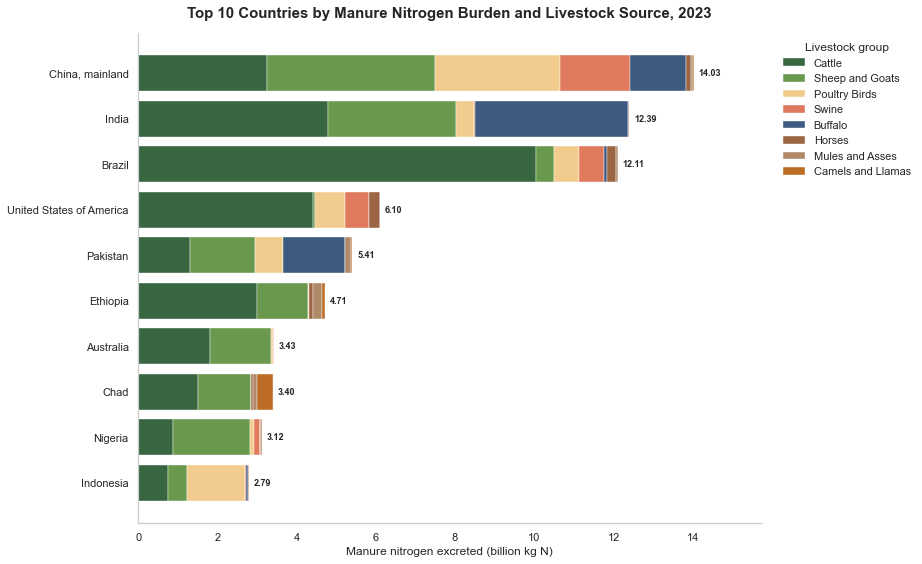

In [34]:
#Create the stacked bar chart
colors = {
    "Cattle": "#386641",
    "Sheep and Goats": "#6A994E",
    "Poultry Birds": "#F2CC8F",
    "Swine": "#E07A5F",
    "Buffalo": "#3D5A80",
    "Horses": "#9C6644",
    "Mules and Asses": "#B08968",
    "Camels and Llamas": "#BC6C25",
}

fig, ax = plt.subplots(figsize=(13, 8))

left = np.zeros(len(composition_table))

for animal in ANIMAL_GROUPS:
    values = composition_table[animal].to_numpy()

    ax.barh(
        composition_table.index,
        values,
        left=left,
        label=animal,
        color=colors[animal],
        edgecolor="white",
        linewidth=0.4,
    )

    left += values

# Add totals at the end of each bar
for position, total in enumerate(left):
    ax.text(
        total + 0.12,
        position,
        f"{total:.2f}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Top 10 Countries by Manure Nitrogen Burden and Livestock Source, 2023",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Manure nitrogen excreted (billion kg N)")
ax.set_ylabel("")

ax.legend(
    title="Livestock group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

# Leave space for labels at the end of bars
ax.set_xlim(0, left.max() * 1.12)

plt.tight_layout()
plt.show()

In [35]:
#Calculate manure nitrogen by animal group
YEAR = 2023
ELEMENT = "Amount excreted in manure (N content)"

# Use top-level groups only to prevent double-counting
ANIMAL_GROUPS = [
    "Cattle",
    "Sheep and Goats",
    "Poultry Birds",
    "Swine",
    "Buffalo",
    "Horses",
    "Mules and Asses",
    "Camels and Llamas",
]

animal_2023 = (
    country_df[
        (country_df["Year"] == YEAR)
        & (country_df["Element"] == ELEMENT)
        & (country_df["Item"].isin(ANIMAL_GROUPS))
    ]
    .groupby("Item", as_index=False)["Value"]
    .sum()
)

animal_2023["Billion kg N"] = animal_2023["Value"] / 1e9

animal_2023 = animal_2023.sort_values(
    "Billion kg N",
    ascending=False,
)

display(
    animal_2023[
        ["Item", "Billion kg N"]
    ].round(3)
)


,Item,Billion kg N
2,Cattle,66.391
6,Sheep and Goats,33.909
5,Poultry Birds,12.604
0,Buffalo,7.685
7,Swine,7.354
3,Horses,2.207
1,Camels and Llamas,1.719
4,Mules and Asses,1.324


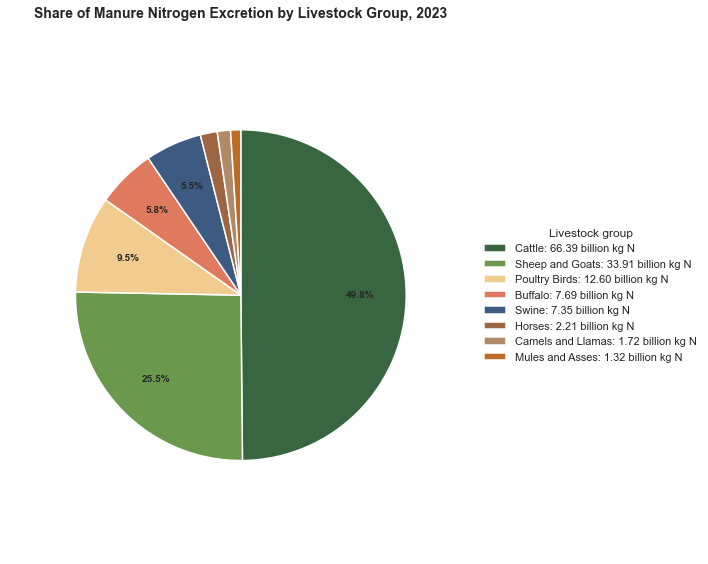

In [36]:
#Create the pie chart
colors = [
    "#386641",  # Cattle
    "#6A994E",  # Sheep and goats
    "#F2CC8F",  # Poultry
    "#E07A5F",  # Swine
    "#3D5A80",  # Buffalo
    "#9C6644",  # Horses
    "#B08968",  # Mules and asses
    "#BC6C25",  # Camels and llamas
]

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, percentage_texts = ax.pie(
    animal_2023["Billion kg N"],
    labels=None,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda percentage: (
        f"{percentage:.1f}%"
        if percentage >= 3
        else ""
    ),
    pctdistance=0.72,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5,
    },
)

for text in percentage_texts:
    text.set_fontsize(10)
    text.set_fontweight("bold")

legend_labels = [
    f"{animal}: {value:.2f} billion kg N"
    for animal, value in zip(
        animal_2023["Item"],
        animal_2023["Billion kg N"],
    )
]

ax.legend(
    wedges,
    legend_labels,
    title="Livestock group",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
)

ax.set_title(
    "Share of Manure Nitrogen Excretion by Livestock Group, 2023",
    fontsize=14,
    fontweight="bold",
    pad=16,
)

ax.axis("equal")

plt.tight_layout()
plt.show()

In [38]:
#############################Layer 2######################################
#Growth by animal group

animal_year = (
    country_df[
        country_df["Item"].isin(animal_groups)
        & (country_df["Element"] == EXCRETED)
    ]
    .groupby(["Item", "Year"], as_index=False)["Value"]
    .sum()
)

animal_growth = (
    animal_year
    .pivot(index="Item", columns="Year", values="Value")
    .reset_index()
)

animal_growth["2013 (bn kg N)"] = animal_growth[2013] / 1e9
animal_growth["2023 (bn kg N)"] = animal_growth[2023] / 1e9
animal_growth["Absolute change (bn kg N)"] = (
    animal_growth[2023] - animal_growth[2013]
) / 1e9

animal_growth["Growth (%)"] = (
    animal_growth[2023] / animal_growth[2013] - 1
) * 100

animal_growth = animal_growth.sort_values(
    "Absolute change (bn kg N)",
    ascending=False,
)

display(
    animal_growth[
        [
            "Item",
            "2013 (bn kg N)",
            "2023 (bn kg N)",
            "Absolute change (bn kg N)",
            "Growth (%)",
        ]
    ].round(2)
)

Year,Item,2013 (bn kg N),2023 (bn kg N),Absolute change (bn kg N),Growth (%)
2,Cattle,60.70,66.39,5.69,9.37
6,Sheep and Goats,29.41,33.91,4.50,15.29
5,Poultry Birds,10.21,12.60,2.40,23.48
0,Buffalo,7.25,7.69,0.44,6.01
1,Camels and Llamas,1.31,1.72,0.41,31.09
7,Swine,7.05,7.35,0.30,4.27
4,Mules and Asses,1.23,1.32,0.10,7.91
3,Horses,2.18,2.21,0.03,1.27


In [39]:
#Country growth
ELEMENT = "Amount excreted in manure (N content)"
START_YEAR = 2013
END_YEAR = 2023

country_year_data = (
    country_df[
        (country_df["Item"] == "All Animals")
        & (country_df["Element"] == ELEMENT)
        & (country_df["Year"].isin([START_YEAR, END_YEAR]))
    ]
    .groupby(["Area", "Year"], as_index=False)["Value"]
    .sum()
)

country_growth = (
    country_year_data
    .pivot(
        index="Area",
        columns="Year",
        values="Value",
    )
    .dropna(subset=[START_YEAR, END_YEAR])
    .reset_index()
)
country_growth["2013 billion kg N"] = (
    country_growth[START_YEAR] / 1e9
)

country_growth["2023 billion kg N"] = (
    country_growth[END_YEAR] / 1e9
)

country_growth["Absolute increase (billion kg N)"] = (
    country_growth[END_YEAR]
    - country_growth[START_YEAR]
) / 1e9

country_growth["Percentage growth (%)"] = (
    (
        country_growth[END_YEAR]
        - country_growth[START_YEAR]
    )
    / country_growth[START_YEAR]
    * 100
)
top_10_absolute_growth = (
    country_growth[
        country_growth["Absolute increase (billion kg N)"] > 0
    ]
    .nlargest(
        10,
        "Absolute increase (billion kg N)",
    )
    .copy()
)

display(
    top_10_absolute_growth[
        [
            "Area",
            "2013 billion kg N",
            "2023 billion kg N",
            "Absolute increase (billion kg N)",
            "Percentage growth (%)",
        ]
    ].round(3)
)

Year,Area,2013 billion kg N,2023 billion kg N,Absolute increase (billion kg N),Percentage growth (%)
32,Chad,1.823,3.401,1.578,86.577
132,Pakistan,3.831,5.408,1.577,41.180
61,Ethiopia,3.462,4.713,1.251,36.124
37,"China, mainland",12.827,14.027,1.200,9.352
82,India,11.200,12.393,1.193,10.649
22,Brazil,10.919,12.111,1.192,10.917
83,Indonesia,1.797,2.792,0.995,55.369
187,United Republic of Tanzania,1.478,2.254,0.776,52.530
127,Nigeria,2.578,3.123,0.544,21.119
108,Mali,0.938,1.475,0.536,57.138


In [47]:
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.


Looks like you are using an old matplotlib version.
               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


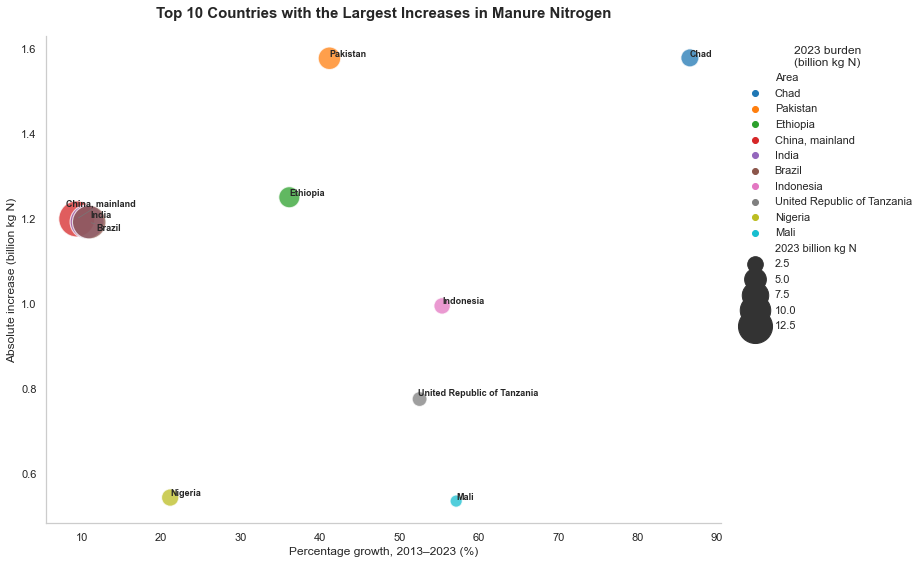

In [50]:
#bubble graph
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = top_10_absolute_growth.copy()

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=plot_data,
    x="Percentage growth (%)",
    y="Absolute increase (billion kg N)",
    size="2023 billion kg N",
    sizes=(150, 1300),
    hue="Area",
    palette="tab10",
    alpha=0.75,
    edgecolor="white",
    linewidth=1.2,
    legend="brief",
    ax=ax,
)

labels = []

for _, row in plot_data.iterrows():
    labels.append(
        ax.text(
            row["Percentage growth (%)"],
            row["Absolute increase (billion kg N)"],
            row["Area"],
            fontsize=9,
            fontweight="bold",
        )
    )

adjust_text(
    labels,
    ax=ax,
    arrowprops={
        "arrowstyle": "-",
        "color": "#777777",
        "linewidth": 0.7,
    },
)

ax.set_title(
    "Top 10 Countries with the Largest Increases in Manure Nitrogen",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel("Percentage growth, 2013–2023 (%)")
ax.set_ylabel("Absolute increase (billion kg N)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    linestyle="--",
    alpha=0.3,
)

ax.legend(
    title="2023 burden\n(billion kg N)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [51]:
###########################Layer3############################################
#Calculate global pathway totals
pathway_elements = [
    EXCRETED,
    MANAGED,
    PASTURE,
    TREATED_LOSS,
    PASTURE_VOLATILIZED,
    PASTURE_LEACHED,
    SOIL_VOLATILIZED,
    SOIL_LEACHED,
]

global_pathways = (
    country_df[
        (country_df["Item"] == "All Animals")
        & country_df["Element"].isin(pathway_elements)
    ]
    .groupby(["Year", "Element"], as_index=False)["Value"]
    .sum()
)

global_pathways["Billion kg N"] = (
    global_pathways["Value"] / 1e9
)

pathway_table = (
    global_pathways
    .pivot(
        index="Year",
        columns="Element",
        values="Billion kg N",
    )
    .reset_index()
)

pathway_table["Managed share (%)"] = (
    pathway_table[MANAGED] / pathway_table[EXCRETED] * 100
)

pathway_table["Pasture share (%)"] = (
    pathway_table[PASTURE] / pathway_table[EXCRETED] * 100
)

display(pathway_table.round(2))

Element,Year,Amount excreted in manure (N content),Losses from manure treated (N content),Manure applied to soils that leaches (N content),Manure applied to soils that volatilises (N content),Manure left on pasture (N content),Manure left on pasture that leaches (N content),Manure left on pasture that volatilises (N content),"Manure management (manure treated, N content)",Managed share (%),Pasture share (%)
0,2013,119.34,6.79,7.84,5.23,83.29,24.99,16.66,32.56,27.29,69.79
1,2023,133.19,6.84,8.33,5.55,94.99,28.50,19.00,34.28,25.73,71.31


In [64]:
#country-level pathway indicators for 2023
#Define pathway elements, Extract the country names

YEAR = 2023

EXCRETED = "Amount excreted in manure (N content)"

MANAGED = "Manure management (manure treated, N content)"

PASTURE = "Manure left on pasture (N content)"

TREATED_LOSS = "Losses from manure treated (N content)"
top_10_country_names = (
    top_10_absolute_growth["Area"]
    .drop_duplicates()
    .tolist()
)

print(top_10_country_names)

['Chad', 'Pakistan', 'Ethiopia', 'China, mainland', 'India', 'Brazil', 'Indonesia', 'United Republic of Tanzania', 'Nigeria', 'Mali']


In [57]:
#Extract 2023 pathway values
top_10_pathway_raw = country_df[
    (country_df["Year"] == YEAR)
    & (country_df["Area"].isin(top_10_country_names))
    & (country_df["Item"] == "All Animals")
    & (
        country_df["Element"].isin([
            EXCRETED,
            MANAGED,
            PASTURE,
            TREATED_LOSS,
        ])
    )
].copy()

display(top_10_pathway_raw.head())

,Area Code,Area,Item,Element,Year,Unit,Value,Flag
3007,21,Brazil,All Animals,Amount excreted in manure (N content),2023,kg,1.211117e+10,E
3009,21,Brazil,All Animals,Manure left on pasture (N content),2023,kg,1.030331e+10,E
3015,21,Brazil,All Animals,"Manure management (manure treated, N content)",2023,kg,1.807858e+09,E
3017,21,Brazil,All Animals,Losses from manure treated (N content),2023,kg,2.149265e+08,E
4277,39,Chad,All Animals,Amount excreted in manure (N content),2023,kg,3.401411e+09,E


In [58]:
#Convert the elements into columns
top_10_pathways = (
    top_10_pathway_raw
    .pivot_table(
        index="Area",
        columns="Element",
        values="Value",
        aggfunc="sum",
    )
    .reset_index()
)

top_10_pathways.columns.name = None

In [59]:
# Calculate pathway indicators
#Convert raw kg N values into billion kg N
top_10_pathways["Total burden (bn kg N)"] = (
    top_10_pathways[EXCRETED] / 1e9
)

top_10_pathways["Managed manure (bn kg N)"] = (
    top_10_pathways[MANAGED] / 1e9
)

top_10_pathways["Manure left on pasture (bn kg N)"] = (
    top_10_pathways[PASTURE] / 1e9
)

top_10_pathways["Losses from managed manure (bn kg N)"] = (
    top_10_pathways[TREATED_LOSS] / 1e9
)

# Share of total excreted nitrogen entering management systems
top_10_pathways["Managed share (%)"] = (
    top_10_pathways[MANAGED]
    / top_10_pathways[EXCRETED]
    * 100
)

# Share of total excreted nitrogen left on pasture
top_10_pathways["Pasture share (%)"] = (
    top_10_pathways[PASTURE]
    / top_10_pathways[EXCRETED]
    * 100
)

# Loss relative to the amount entering management systems
top_10_pathways["Managed nitrogen-loss rate (%)"] = np.where(
    top_10_pathways[MANAGED] > 0,
    (
        top_10_pathways[TREATED_LOSS]
        / top_10_pathways[MANAGED]
        * 100
    ),
    np.nan,
)

In [60]:
#Merge with your growth table
top_10_pathway_indicators = (
    top_10_absolute_growth[
        [
            "Area",
            "2013 billion kg N",
            "2023 billion kg N",
            "Absolute increase (billion kg N)",
            "Percentage growth (%)",
        ]
    ]
    .merge(
        top_10_pathways[
            [
                "Area",
                "Managed manure (bn kg N)",
                "Manure left on pasture (bn kg N)",
                "Losses from managed manure (bn kg N)",
                "Managed share (%)",
                "Pasture share (%)",
                "Managed nitrogen-loss rate (%)",
            ]
        ],
        on="Area",
        how="left",
    )
)

In [61]:
display(
    top_10_pathway_indicators.round(2)
)

,Area,2013 billion kg N,2023 billion kg N,Absolute increase (billion kg N),Percentage growth (%),Managed manure (bn kg N),Manure left on pasture (bn kg N),Losses from managed manure (bn kg N),Managed share (%),Pasture share (%),Managed nitrogen-loss rate (%)
0,Chad,1.82,3.40,1.58,86.58,0.08,3.32,0.01,2.25,97.57,9.83
1,Pakistan,3.83,5.41,1.58,41.18,1.23,3.41,0.07,22.76,63.00,6.02
2,Ethiopia,3.46,4.71,1.25,36.12,0.14,4.53,0.02,3.05,96.05,12.98
3,"China, mainland",12.83,14.03,1.20,9.35,6.44,7.48,1.25,45.93,53.30,19.40
4,India,11.20,12.39,1.19,10.65,2.66,7.42,0.24,21.43,59.90,9.05
5,Brazil,10.92,12.11,1.19,10.92,1.81,10.30,0.21,14.93,85.07,11.89
6,Indonesia,1.80,2.79,1.00,55.37,1.27,1.50,0.17,45.63,53.77,13.01
7,United Republic of Tanzania,1.48,2.25,0.78,52.53,0.10,2.12,0.01,4.45,94.05,13.32
8,Nigeria,2.58,3.12,0.54,21.12,0.23,2.90,0.01,7.38,92.73,6.15
9,Mali,0.94,1.47,0.54,57.14,0.05,1.43,0.00,3.07,96.69,9.02


In [66]:
pathway_plot = top_10_pathway_indicators.copy()

# Calculate the portion not covered by the two reported pathways
pathway_plot["Other pathways / difference (%)"] = (
    100
    - pathway_plot["Managed share (%)"]
    - pathway_plot["Pasture share (%)"]
)

# Prevent tiny negative values caused by rounding
pathway_plot["Other pathways / difference (%)"] = (
    pathway_plot["Other pathways / difference (%)"]
    .clip(lower=0)
)

# Keep the country order from top_10_absolute_growth,
# but reverse it for a horizontal chart
pathway_plot = pathway_plot.iloc[::-1].reset_index(drop=True)

display(pathway_plot.round(2))

,Area,2013 billion kg N,2023 billion kg N,Absolute increase (billion kg N),Percentage growth (%),Managed manure (bn kg N),Manure left on pasture (bn kg N),Losses from managed manure (bn kg N),Managed share (%),Pasture share (%),Managed nitrogen-loss rate (%),Other pathways / difference (%)
0,Mali,0.94,1.47,0.54,57.14,0.05,1.43,0.00,3.07,96.69,9.02,0.23
1,Nigeria,2.58,3.12,0.54,21.12,0.23,2.90,0.01,7.38,92.73,6.15,0.00
2,United Republic of Tanzania,1.48,2.25,0.78,52.53,0.10,2.12,0.01,4.45,94.05,13.32,1.50
3,Indonesia,1.80,2.79,1.00,55.37,1.27,1.50,0.17,45.63,53.77,13.01,0.60
4,Brazil,10.92,12.11,1.19,10.92,1.81,10.30,0.21,14.93,85.07,11.89,0.00
5,India,11.20,12.39,1.19,10.65,2.66,7.42,0.24,21.43,59.90,9.05,18.68
6,"China, mainland",12.83,14.03,1.20,9.35,6.44,7.48,1.25,45.93,53.30,19.40,0.77
7,Ethiopia,3.46,4.71,1.25,36.12,0.14,4.53,0.02,3.05,96.05,12.98,0.90
8,Pakistan,3.83,5.41,1.58,41.18,1.23,3.41,0.07,22.76,63.00,6.02,14.24
9,Chad,1.82,3.40,1.58,86.58,0.08,3.32,0.01,2.25,97.57,9.83,0.18


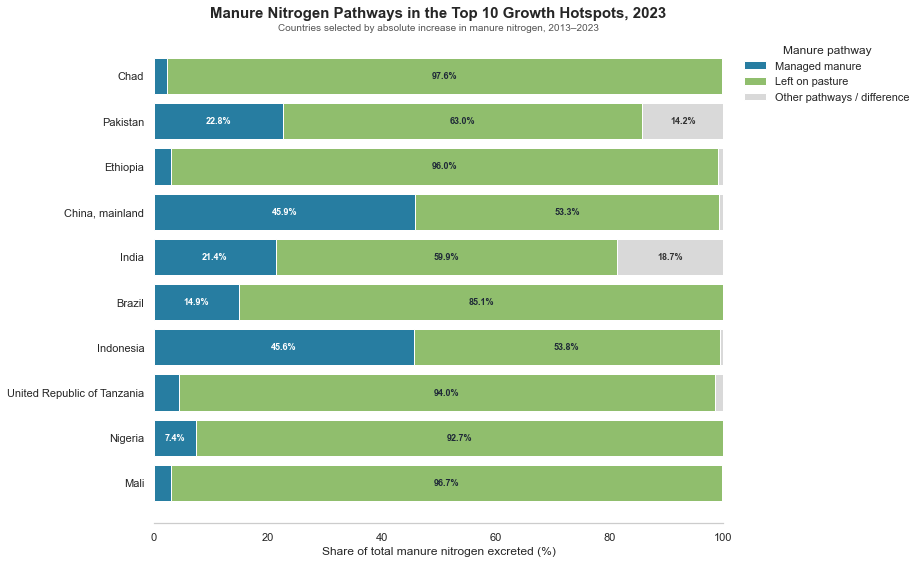

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pathway_plot = top_10_pathway_indicators.copy()

pathway_plot["Other pathways / difference (%)"] = (
    100
    - pathway_plot["Managed share (%)"]
    - pathway_plot["Pasture share (%)"]
).clip(lower=0)

pathway_plot = pathway_plot.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 8))

countries = pathway_plot["Area"]
managed = pathway_plot["Managed share (%)"]
pasture = pathway_plot["Pasture share (%)"]
other = pathway_plot["Other pathways / difference (%)"]

managed_bars = ax.barh(
    countries,
    managed,
    color="#277DA1",
    edgecolor="white",
    label="Managed manure",
)

pasture_bars = ax.barh(
    countries,
    pasture,
    left=managed,
    color="#90BE6D",
    edgecolor="white",
    label="Left on pasture",
)

other_bars = ax.barh(
    countries,
    other,
    left=managed + pasture,
    color="#D9D9D9",
    edgecolor="white",
    label="Other pathways / difference",
)

for bars, values, text_color in [
    (managed_bars, managed, "white"),
    (pasture_bars, pasture, "#1F2937"),
    (other_bars, other, "#333333"),
]:
    for bar, value in zip(bars, values):
        if value >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
                fontweight="bold",
            )

ax.set_title(
    "Manure Nitrogen Pathways in the Top 10 Growth Hotspots, 2023",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

ax.text(
    0.5,
    1.01,
    "Countries selected by absolute increase in manure nitrogen, 2013–2023",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("Share of total manure nitrogen excreted (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.legend(
    title="Manure pathway",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

In [ ]:
#layer 4

In [76]:
global_2023 = (
    country_df[
        (country_df["Year"] == 2023)
        & (country_df["Item"] == "All Animals")
        & (
            country_df["Element"].isin([
                EXCRETED,
                MANAGED,
                PASTURE,
            ])
        )
    ]
    .groupby("Element")["Value"]
    .sum()
)

GLOBAL_MANAGED_SHARE = (
    global_2023[MANAGED]
    / global_2023[EXCRETED]
    * 100
)

GLOBAL_PASTURE_SHARE = (
    global_2023[PASTURE]
    / global_2023[EXCRETED]
    * 100
)

print(
    "Global managed share:",
    round(GLOBAL_MANAGED_SHARE, 2),
    "%"
)

print(
    "Global pasture share:",
    round(GLOBAL_PASTURE_SHARE, 2),
    "%"
)
layer_4_table = top_10_pathway_indicators.copy()

Global managed share: 25.73 %
Global pasture share: 71.31 %


In [77]:
#Classify the hotspot types
conditions = [
    layer_4_table["Managed share (%)"] >= GLOBAL_MANAGED_SHARE,

    layer_4_table["Pasture share (%)"] >= GLOBAL_PASTURE_SHARE,
]

hotspot_types = [
    "Larger managed-manure stream",
    "Pasture-dominated system",
]

layer_4_table["Hotspot type"] = np.select(
    conditions,
    hotspot_types,
    default="Mixed pathway system",
)

In [78]:
#assign possible response
response_mapping = {
    "Larger managed-manure stream":
        "Assess collection, biogas, and resource-recovery potential",

    "Pasture-dominated system":
        "Prioritize grazing and pasture nutrient management",

    "Mixed pathway system":
        "Combine collection and pasture-based strategies",
}

layer_4_table["Potential response"] = (
    layer_4_table["Hotspot type"]
    .map(response_mapping)
)

In [79]:
#add managed loss flag
#这个 flag 用于识别 managed manure nitrogen loss rate 高于 Top 10 中位数的国家
loss_rate_median = (
    layer_4_table["Managed nitrogen-loss rate (%)"]
    .median()
)

layer_4_table["Managed-loss flag"] = np.where(
    layer_4_table["Managed nitrogen-loss rate (%)"]
    >= loss_rate_median,
    "Above Top-10 median",
    "Below Top-10 median",
)

print(
    "Top-10 median managed nitrogen-loss rate:",
    round(loss_rate_median, 2),
    "%"
)

Top-10 median managed nitrogen-loss rate: 10.86 %


In [80]:
#display table
layer_4_display = layer_4_table[
    [
        "Area",
        "2023 billion kg N",
        "Absolute increase (billion kg N)",
        "Percentage growth (%)",
        "Managed share (%)",
        "Pasture share (%)",
        "Managed nitrogen-loss rate (%)",
        "Hotspot type",
        "Potential response",
    ]
].sort_values(
    "Absolute increase (billion kg N)",
    ascending=False,
)

display(layer_4_display.round(2))

,Area,2023 billion kg N,Absolute increase (billion kg N),Percentage growth (%),Managed share (%),Pasture share (%),Managed nitrogen-loss rate (%),Hotspot type,Potential response
0,Chad,3.40,1.58,86.58,2.25,97.57,9.83,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...
1,Pakistan,5.41,1.58,41.18,22.76,63.00,6.02,Mixed pathway system,Combine collection and pasture-based strategies
2,Ethiopia,4.71,1.25,36.12,3.05,96.05,12.98,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...
3,"China, mainland",14.03,1.20,9.35,45.93,53.30,19.40,Larger managed-manure stream,"Assess collection, biogas, and resource-recove..."
4,India,12.39,1.19,10.65,21.43,59.90,9.05,Mixed pathway system,Combine collection and pasture-based strategies
5,Brazil,12.11,1.19,10.92,14.93,85.07,11.89,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...
6,Indonesia,2.79,1.00,55.37,45.63,53.77,13.01,Larger managed-manure stream,"Assess collection, biogas, and resource-recove..."
7,United Republic of Tanzania,2.25,0.78,52.53,4.45,94.05,13.32,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...
8,Nigeria,3.12,0.54,21.12,7.38,92.73,6.15,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...
9,Mali,1.47,0.54,57.14,3.07,96.69,9.02,Pasture-dominated system,Prioritize grazing and pasture nutrient manage...


In [81]:
for hotspot_type, group in layer_4_table.groupby("Hotspot type"):
    print(f"\n{hotspot_type}")

    for country in group["Area"]:
        print(f"  - {country}")


Larger managed-manure stream
  - China, mainland
  - Indonesia

Mixed pathway system
  - Pakistan
  - India

Pasture-dominated system
  - Chad
  - Ethiopia
  - Brazil
  - United Republic of Tanzania
  - Nigeria
  - Mali


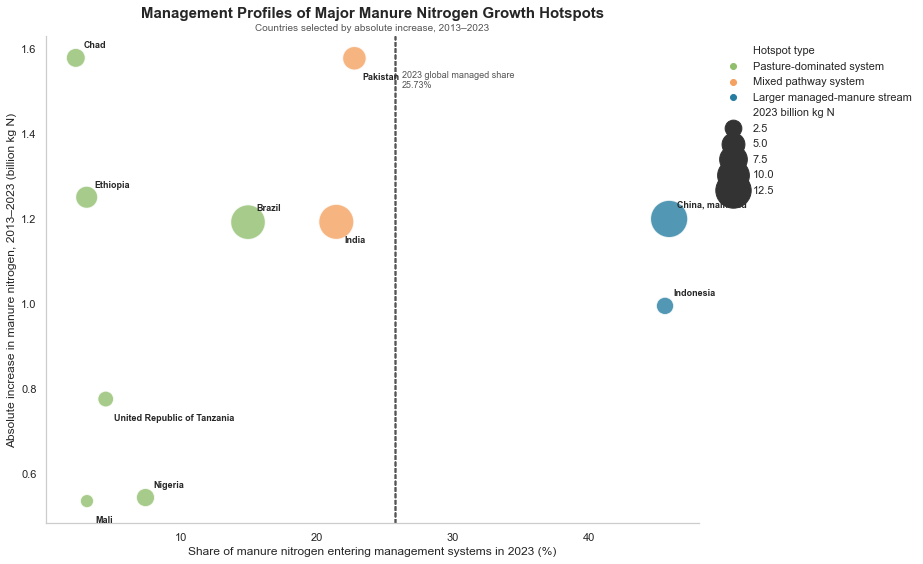

In [83]:
#visual
import matplotlib.pyplot as plt
import seaborn as sns

color_mapping = {
    "Larger managed-manure stream": "#277DA1",
    "Pasture-dominated system": "#90BE6D",
    "Mixed pathway system": "#F4A261",
}

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=layer_4_table,
    x="Managed share (%)",
    y="Absolute increase (billion kg N)",
    size="2023 billion kg N",
    hue="Hotspot type",
    palette=color_mapping,
    sizes=(180, 1400),
    alpha=0.8,
    edgecolor="white",
    linewidth=1.3,
    ax=ax,
)
label_offsets = {
    "Chad": (8, 8),
    "Pakistan": (8, -14),
    "Ethiopia": (8, 8),
    "China, mainland": (8, 10),
    "India": (8, -14),
    "Brazil": (8, 10),
    "Indonesia": (8, 8),
    "United Republic of Tanzania": (8, -14),
    "Nigeria": (8, 8),
    "Mali": (8, -14),
}

for _, row in layer_4_table.iterrows():
    x_offset, y_offset = label_offsets.get(
        row["Area"],
        (7, 7),
    )

    ax.annotate(
        row["Area"],
        xy=(
            row["Managed share (%)"],
            row["Absolute increase (billion kg N)"],
        ),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        va="bottom" if y_offset >= 0 else "top",
    )
    ax.axvline(
    GLOBAL_MANAGED_SHARE,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
)

ax.text(
    GLOBAL_MANAGED_SHARE + 0.5,
    ax.get_ylim()[1] * 0.95,
    "2023 global managed share\n25.73%",
    fontsize=9,
    color="#555555",
    va="top",
)

ax.set_title(
    "Management Profiles of Major Manure Nitrogen Growth Hotspots",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

ax.text(
    0.5,
    1.01,
    "Countries selected by absolute increase, 2013–2023",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel(
    "Share of manure nitrogen entering management systems in 2023 (%)"
)

ax.set_ylabel(
    "Absolute increase in manure nitrogen, 2013–2023 (billion kg N)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    linestyle="--",
    alpha=0.25,
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()